# 3. Análisis univariado

Este capítulo caracteriza cada variable por separado: la distribución de la variable objetivo, la forma y dispersión de las numéricas y la composición de las categóricas.

**Todo el análisis usa exclusivamente el conjunto de entrenamiento.** El conjunto de prueba permanece intacto hasta la evaluación final, para que ninguna decisión se haya tomado mirándolo.

In [1]:
from config import *

roles = roles_variables()
OBJETIVO = roles["objetivo"]
NUMERICAS = roles["numericas"] + roles["ordinales"]
CATEGORICAS = roles["categoricas"]
BINARIAS = roles["binarias"]
ETIQUETAS_EDAD = {int(k): v for k, v in roles["etiquetas_edad"].items()}

train = leer_tabla("diabetes_train")
assert train.isna().sum().sum() == 0, "El conjunto cargado tiene faltantes"
print(f"Conjunto de entrenamiento: {train.shape[0]:,} filas x "
      f"{train.shape[1]} columnas")

Conjunto de entrenamiento: 79,473 filas x 40 columnas


## 3.1. Variable objetivo

El grado de desbalance determina las métricas de evaluación y justifica la etapa de balanceo del pipeline experimental.

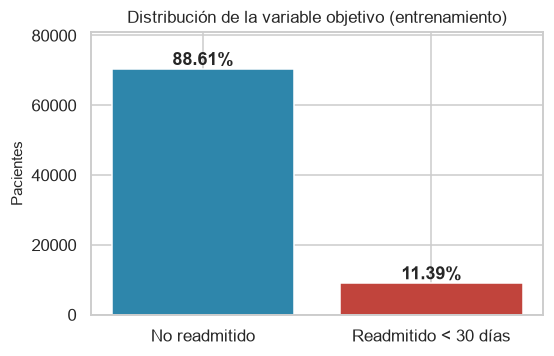

Clase minoritaria  : 9,051 pacientes (11.39%)
Razón de desbalance: 1 a 7.8


In [2]:
conteo = train[OBJETIVO].value_counts().sort_index()
proporcion = train[OBJETIVO].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(5.2, 3.4))
barras = ax.bar(["No readmitido", "Readmitido < 30 días"], conteo.values,
                color=COLORES)
for barra, p in zip(barras, proporcion.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
            f"{p:.2%}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Pacientes")
ax.set_title("Distribución de la variable objetivo (entrenamiento)")
ax.set_ylim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Clase minoritaria  : {conteo[1]:,} pacientes ({proporcion[1]:.2%})")
print(f"Razón de desbalance: 1 a {conteo[0] / conteo[1]:.1f}")

La clase positiva representa el 8.98 % del conjunto de entrenamiento, una razón cercana a 1 contra 10. Dos consecuencias metodológicas:

1. **La exactitud queda descartada como métrica principal.** Un clasificador trivial que prediga siempre "no readmitido" alcanza un 91 % de exactitud con capacidad predictiva nula. Las métricas apropiadas son el AUC-ROC, el AUC de precisión-exhaustividad (más informativo que el ROC cuando la clase positiva es escasa, porque la precisión es sensible a la prevalencia), el F1 de la clase positiva y la exactitud balanceada.
2. **La etapa de balanceo está justificada empíricamente**, no por convención. Comparar SMOTE, ADASYN, ponderación por clase y ausencia de tratamiento es una pregunta legítima en este contexto, y la ausencia de tratamiento debe formar parte de la comparación en lugar de darse por descartada.

## 3.2. Variables numéricas

### 3.2.1. Estadísticos descriptivos y forma de la distribución

In [3]:
resumen = train[NUMERICAS].describe().T
resumen["asimetría"] = train[NUMERICAS].skew()
resumen["curtosis"] = train[NUMERICAS].kurtosis()
resumen["% ceros"] = (100 * (train[NUMERICAS] == 0).mean()).round(2)
tabla(resumen.round(2), filas=15)

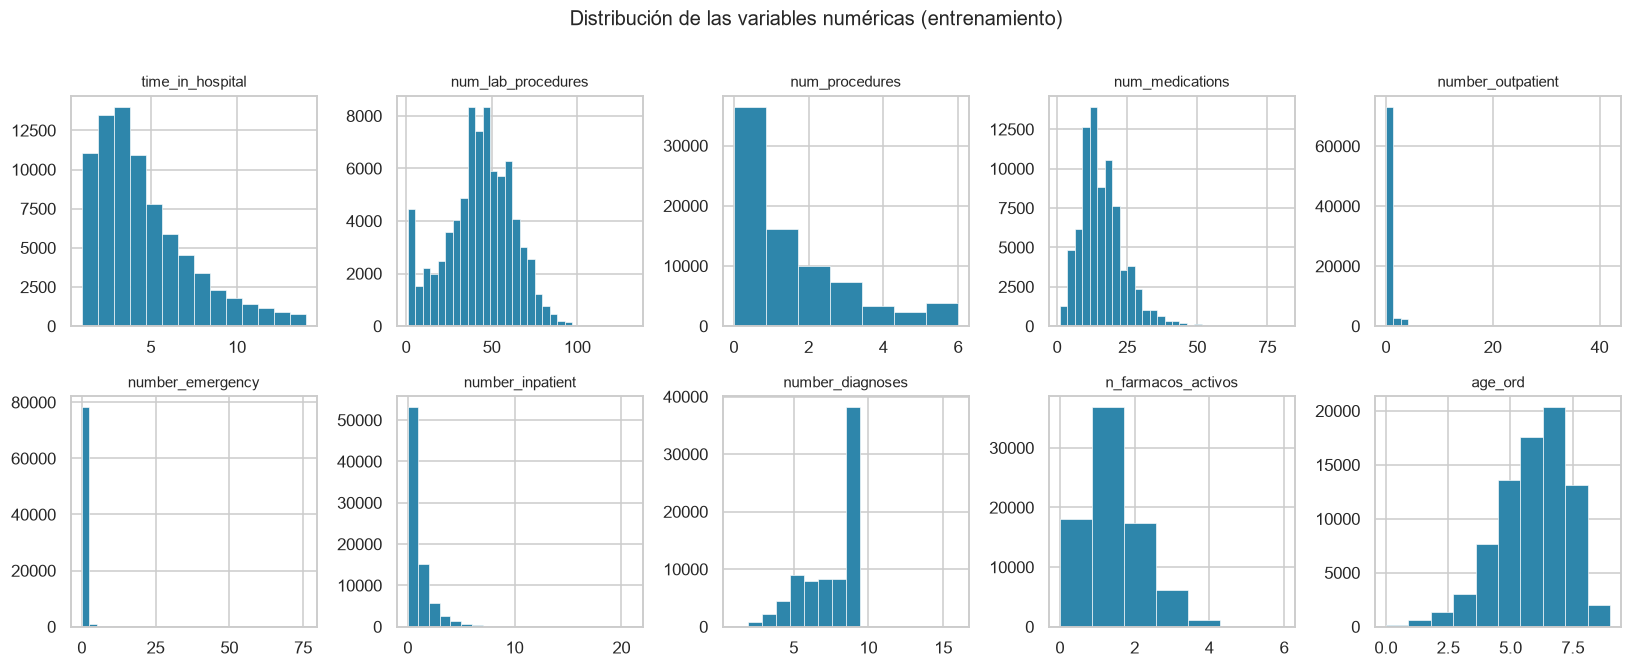

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, columna in zip(axes.flat, NUMERICAS):
    # El número de barras se adapta al soporte discreto de cada variable
    # para no introducir huecos artificiales entre valores enteros.
    n_bins = min(30, train[columna].nunique())
    ax.hist(train[columna], bins=n_bins, color=PALETA[0],
            edgecolor="white", linewidth=0.4)
    ax.set_title(columna, fontsize=10)
for ax in axes.flat[len(NUMERICAS):]:
    ax.set_visible(False)
fig.suptitle("Distribución de las variables numéricas (entrenamiento)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Las distribuciones se separan en tres grupos. `num_lab_procedures` es aproximadamente simétrica y de soporte amplio. `time_in_hospital`, `num_medications`, `num_procedures`, `number_diagnoses` y `n_farmacos_activos` son conteos con asimetría positiva moderada. Y las tres variables de utilización previa muestran una concentración extrema en cero, con asimetrías superiores a 9 y curtosis de tres cifras.

### 3.2.2. Normalidad

Se aplica la prueba de Shapiro-Wilk, con dos advertencias importantes para su interpretación.

Primero, la prueba tiene un límite práctico de tamaño muestral, por lo que se evalúa sobre una submuestra de 5,000 observaciones fijada por semilla. Segundo, y más relevante: **con este tamaño de muestra la prueba rechaza la normalidad ante desviaciones triviales**, de modo que un valor p pequeño no informa sobre la magnitud del alejamiento. El argumento sustantivo no es el valor p, sino la naturaleza de las variables: todas son conteos discretos y varias tienen exceso de ceros, así que no pueden ser normales por construcción. La prueba se reporta porque el protocolo del curso la requiere, pero la decisión se apoya en la asimetría y la curtosis de la tabla anterior.

In [5]:
def shapiro_submuestra(serie, n=5000):
    """Prueba de Shapiro-Wilk sobre una submuestra aleatoria fijada.

    Returns
    -------
    float
        Valor p del contraste de normalidad.
    """
    muestra = serie.sample(min(n, len(serie)), random_state=RANDOM_STATE)
    return stats.shapiro(muestra).pvalue


normalidad = pd.DataFrame({
    "asimetría": train[NUMERICAS].skew(),
    "curtosis": train[NUMERICAS].kurtosis(),
    "p (Shapiro-Wilk)": [shapiro_submuestra(train[c]) for c in NUMERICAS],
})
normalidad["¿normal? (α=0.05)"] = np.where(
    normalidad["p (Shapiro-Wilk)"] > 0.05, "Sí", "No")
normalidad.round(4)

,asimetría,curtosis,p (Shapiro-Wilk),¿normal? (α=0.05)
time_in_hospital,1.1416,0.8887,0.0,No
num_lab_procedures,-0.2437,-0.2642,0.0,No
num_procedures,1.3186,0.8639,0.0,No
num_medications,1.3286,3.5012,0.0,No
number_outpatient,8.5918,143.1054,0.0,No
number_emergency,24.6706,1292.8543,0.0,No
number_inpatient,3.7394,22.3336,0.0,No
number_diagnoses,-0.8557,-0.1203,0.0,No
n_farmacos_activos,0.6757,0.2897,0.0,No
age_ord,-0.6303,0.2733,0.0,No


Ninguna variable supera la prueba. Esto determina dos decisiones que se aplican en el resto del proyecto:

- Las comparaciones entre grupos del capítulo 4 usan **pruebas no paramétricas**.
- Para los modelos sensibles a la escala (k-NN, SVM, regresión regularizada) se usará **escalado robusto**, basado en mediana y rango intercuartílico, menos sensible a los valores extremos que la estandarización clásica.

### 3.2.3. Valores atípicos

In [6]:
def limites_iqr(serie, factor=1.5):
    """Límites del rango intercuartílico ampliado (regla de Tukey)."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr


filas = []
for columna in NUMERICAS:
    inferior, superior = limites_iqr(train[columna])
    fuera = (train[columna] < inferior) | (train[columna] > superior)
    filas.append({
        "variable": columna,
        "límite inferior": inferior,
        "límite superior": superior,
        "atípicos": fuera.sum(),
        "% atípicos": 100 * fuera.mean(),
        "máximo observado": train[columna].max(),
    })

atipicos = pd.DataFrame(filas).set_index("variable").round(2)
tabla(atipicos, filas=15)

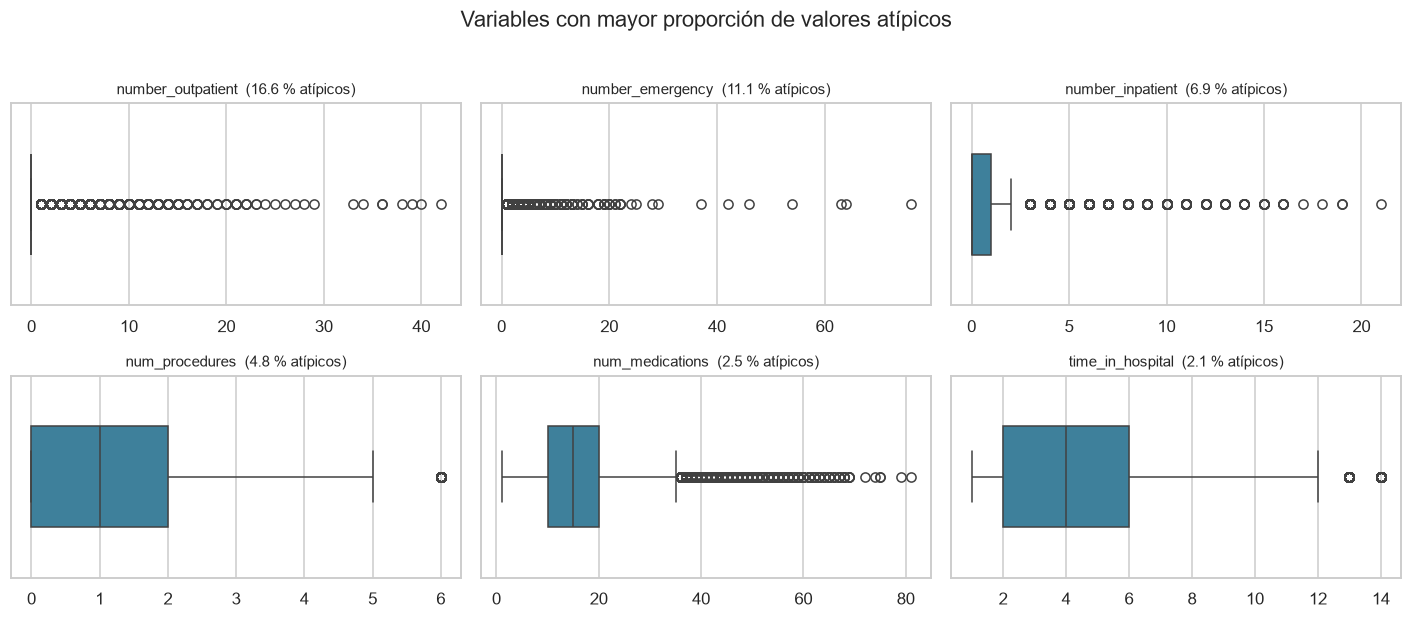

In [7]:
principales = atipicos["% atípicos"].sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(13, 5.5))
for ax, columna in zip(axes.flat, principales):
    sns.boxplot(x=train[columna], color=PALETA[0], ax=ax, width=0.5)
    ax.set_title(f"{columna}  ({atipicos.loc[columna, '% atípicos']:.1f} % atípicos)",
                 fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Variables con mayor proporción de valores atípicos", y=1.02)
plt.tight_layout()
plt.show()

Los atípicos se concentran en las variables de utilización previa, donde superan el 10 % de los casos. El fenómeno es mecánico: cuando más del 85 % de las observaciones vale cero, el rango intercuartílico es nulo y la regla de Tukey marca como atípico cualquier valor positivo. Es un artefacto de aplicar un criterio pensado para distribuciones continuas a conteos con exceso de ceros, no una señal de error en los datos.

**No se recortan ni se winsorizan**, por dos razones. La primera es clínica: un paciente con seis hospitalizaciones en el último año no es un error de captura, es exactamente el perfil de riesgo que el modelo debe identificar; eliminarlo sería descartar la señal más valiosa del problema. La segunda es metodológica: recortar el conjunto completo antes de particionar usaría información de todas las observaciones para decidir sobre cada una, otra forma de fuga.

## 3.3. Variables categóricas

In [8]:
resumen_cat = pd.DataFrame({
    "categorías": train[CATEGORICAS].nunique(),
    "moda": train[CATEGORICAS].apply(lambda s: s.value_counts().index[0]),
    "% moda": (100 * train[CATEGORICAS].apply(
        lambda s: s.value_counts(normalize=True).iloc[0])).round(2),
    "% categoría menos frecuente": (100 * train[CATEGORICAS].apply(
        lambda s: s.value_counts(normalize=True).iloc[-1])).round(2),
}).sort_values("categorías", ascending=False)
tabla(resumen_cat, filas=30)

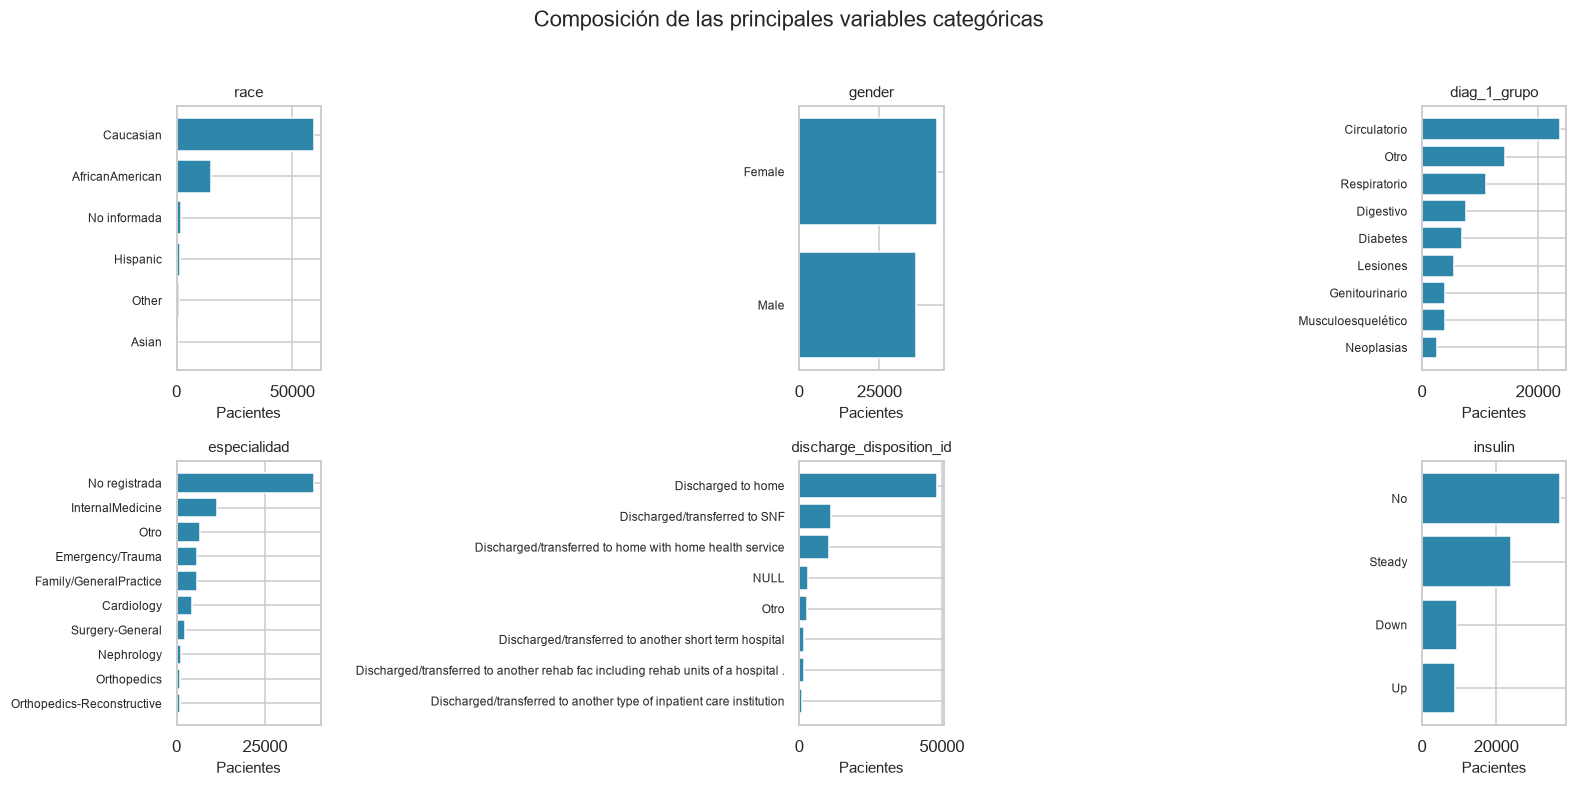

In [9]:
DESTACADAS = ["race", "gender", "diag_1_grupo", "especialidad",
              "discharge_disposition_id", "insulin"]

fig, axes = plt.subplots(2, 3, figsize=(14.5, 7))
for ax, columna in zip(axes.flat, DESTACADAS):
    conteos = train[columna].value_counts().head(10)
    ax.barh([str(i) for i in conteos.index][::-1], conteos.values[::-1],
            color=PALETA[0])
    ax.set_title(columna, fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Pacientes")
fig.suptitle("Composición de las principales variables categóricas", y=1.02)
plt.tight_layout()
plt.show()

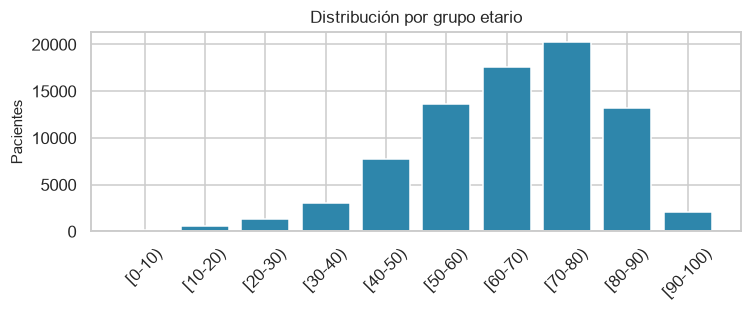

In [10]:
# Edad: se grafica con las etiquetas originales para que sea legible.
edad = (train["age_ord"].value_counts().sort_index()
        .rename(index=ETIQUETAS_EDAD))

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(edad.index, edad.values, color=PALETA[0])
ax.set_ylabel("Pacientes")
ax.set_title("Distribución por grupo etario")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

La cohorte está formada mayoritariamente por adultos mayores: los grupos de 60 a 90 años concentran la mayor parte de los pacientes, coherente con la prevalencia de la diabetes tipo 2. Los grupos extremos tienen poca representación, lo que conviene recordar al interpretar más adelante cualquier resultado sobre ellos.

En el panel de fármacos, la insulina es el único con distribución realmente informativa. El resto se concentra en la categoría `No`, aunque tras la depuración del capítulo 2 todos los retenidos conservan varianza suficiente.

### 3.4. Síntesis del capítulo

| Dimensión | Hallazgo |
|---|---|
| Desbalance | 91.02 % frente a 8.98 % (razón 1:10) en entrenamiento; prevalencia idéntica en prueba por construcción |
| Métricas implicadas | AUC-ROC, AUC-PR, F1 de la clase positiva y exactitud balanceada; exactitud solo como referencia |
| Forma de las distribuciones | Ninguna numérica es normal; tres variables con exceso extremo de ceros y curtosis de tres cifras |
| Escalado implicado | Robusto (mediana e IQR) para los modelos sensibles a la escala |
| Atípicos | Concentrados en la utilización previa; artefacto de aplicar la regla de Tukey a conteos con exceso de ceros. No se tratan |
| Composición de la cohorte | Predominio de pacientes de 60 a 90 años; insulina como único fármaco con variación sustantiva |